In [63]:
# Mounting the drive to read the dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
!pip install biopython
from Bio import AlignIO
from Bio.Align import substitution_matrices
import pprint
import matplotlib.pyplot as plt
import math

In [65]:
# Question 3
# Reading the MSA files for both sets
set_1 = AlignIO.read("/content/drive/MyDrive/BT3040-Assignments/Lab Assignment - 6/Clustalo-Set-1.aln-clustal_num", "clustal")
print(set_1)
print("="*125)
set_2 = AlignIO.read("/content/drive/MyDrive/BT3040-Assignments/Lab Assignment - 6/Clustalo-Set-2.aln-clustal_num", "clustal")
print(set_2)

Alignment with 11 rows and 143 columns
-SLSDKDKAAVRALWSKIGKSADAIGNDALSRMIVVYPQTKTYF...RYR sp|P80043|HBA_TREBE
MVLSANDKSNVKSIFSKISSHAEEYGAETLERMFTTYPQTKTYF...KYR sp|P01980|HBA_APTFO
-VLSPADKTNIKSTWDKIGGHAGDYGGEALDRTFQSFPTTKTYF...KYR sp|P60529|HBA_CANLF
MVLSADDKTNIKNCWGKIGGHGGEYGEEALQRMFAAFPTTKTYF...KYR sp|P01946|HBA_RAT
-VLSAADKANVKAAWGKVGGQAGAHGAEALERMFLGFPTTKTYF...KYR sp|P01965|HBA_PIG
MVLSGEDKSNIKAAWGKIGGHGAEYGAEALERMFASFPTTKTYF...KYR sp|P01942|HBA_MOUSE
MVLSPADKTNVKTAWGKVGAHAGDYGAEALERMFLSFPTTKTYF...KYR sp|P06635|HBA_PONPY
MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYF...KYR sp|P69905|HBA_HUMAN
MVLSAADKGNVKAAWGKVGGHAAEYGAEALERMFLSFPTTKTYF...KYR sp|P01966|HBA_BOVIN
MVLSAADKTNVKAAWSKVGGHAGEYGAEALERMFLGFPTTKTYF...KYR sp|P01958|HBA_HORSE
MVLSAADKTNVKAAWSKVGGNAGEFGAEALERMFLGFPTTKTYF...KYR sp|P01959|HBA_EQUAS
Alignment with 9 rows and 264 columns
MASKPQPIAAANWKCNGSESLLVPLIETLNAATFDHD--VQCVV...--- sp|P52270|TPIS_TRYCR
-----------NWKCNLSKADIAELVSAFNAAPPIDAAHVQVVV...EAV sp|P48492|TPIS_GRAGA
--

In [66]:
def unweighted_freq(data):

  distribution = []

  for n in range(data.get_alignment_length()):
    temp, counter = {}, 0
    AAs = "ACDEFGHIKLMNPQRSTVWY"

    for AA in AAs:
      temp[AA] = 0

    for seq_no in range(len(data)):

      if data[seq_no].seq[n].isalpha():
        counter += 1
        temp[data[seq_no].seq[n]] += 1

    for residue in temp.keys():
      temp[residue] = temp[residue]/counter

    distribution.append((n,temp))

  return(distribution)
#===============================================================================
def general_freq(data):

  frequency_total, total_AA = {}, 0
  AAs = "ACDEFGHIKLMNPQRSTVWY"
  for AA in AAs:
    frequency_total[AA] = 0

  for record in data:

    for AA in record.seq:
      if AA.isalpha():
        frequency_total[AA] +=1
        total_AA += 1

  for AA in frequency_total.keys():
    frequency_total[AA] = frequency_total[AA]/(data.get_alignment_length()*len(data))

  return(frequency_total)
#===============================================================================
freq_1 = unweighted_freq(set_1)
freq_2 = unweighted_freq(set_2)

total_freq_1 = general_freq(set_1)
total_freq_2 = general_freq(set_2)

In [67]:
def entropy_based_score(freq):
  scores = {}

  for n in range(len(freq)):

    residue, frequency = freq[n]
    score = 0

    for AA in frequency.keys():
      if frequency[AA] !=0:
        score += frequency[AA] * (math.log(frequency[AA]))

    scores[residue+1] = round(score,3)

  return(scores)

ebs_1 = entropy_based_score(freq_1)
print(ebs_1)
print("="*100)
ebs_2 = entropy_based_score(freq_2)
print(ebs_2)


{1: 0.0, 2: -0.305, 3: 0.0, 4: 0.0, 5: -1.121, 6: -1.16, 7: 0.0, 8: 0.0, 9: -1.169, 10: -0.305, 11: -0.586, 12: -0.305, 13: -1.034, 14: -1.16, 15: -0.305, 16: -0.916, 17: 0.0, 18: -0.689, 19: -0.305, 20: -1.034, 21: -0.886, 22: -0.474, 23: -1.034, 24: -0.908, 25: -0.886, 26: 0.0, 27: -0.886, 28: -0.305, 29: -0.305, 30: 0.0, 31: -0.886, 32: 0.0, 33: -0.305, 34: -0.305, 35: -1.295, 36: -1.367, 37: -0.474, 38: 0.0, 39: -0.474, 40: 0.0, 41: 0.0, 42: 0.0, 43: 0.0, 44: 0.0, 45: -0.474, 46: 0.0, 47: -0.6, 48: 0.0, 49: -0.305, 50: -0.586, 51: -0.6, 52: -0.586, 53: 0.0, 54: 0.0, 55: -0.6, 56: -0.305, 57: -0.305, 58: 0.0, 59: -0.86, 60: 0.0, 61: 0.0, 62: -0.6, 63: 0.0, 64: 0.0, 65: -0.76, 66: -0.76, 67: -0.305, 68: -0.305, 69: -0.86, 70: -1.673, 71: 0.0, 72: -0.586, 73: -1.594, 74: -0.305, 75: -0.995, 76: -0.305, 77: 0.0, 78: -0.76, 79: -0.6, 80: -0.76, 81: -0.305, 82: 0.0, 83: -0.305, 84: -1.414, 85: 0.0, 86: 0.0, 87: -0.305, 88: -0.305, 89: 0.0, 90: 0.0, 91: -0.76, 92: 0.0, 93: 0.0, 94: 0.0, 9

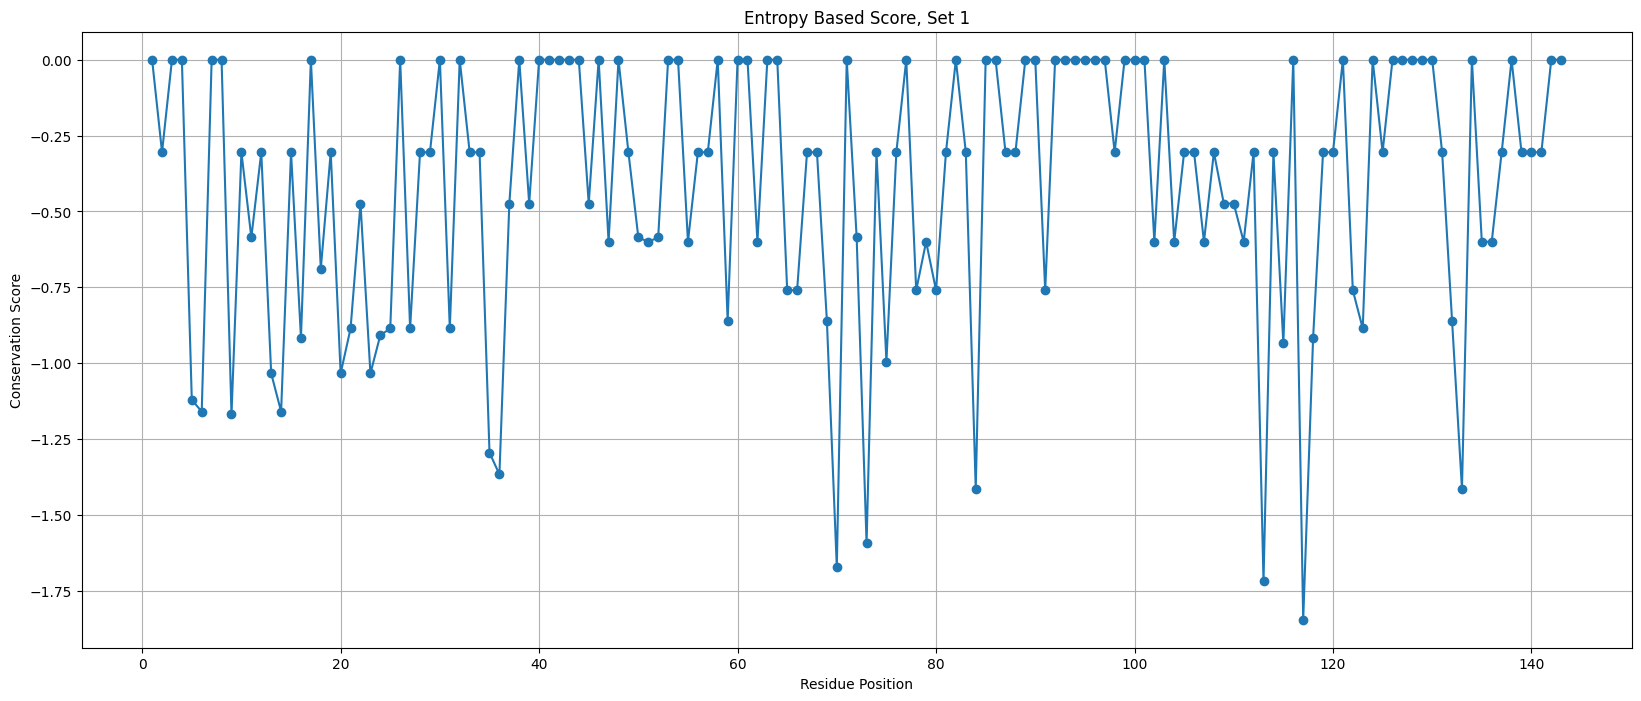

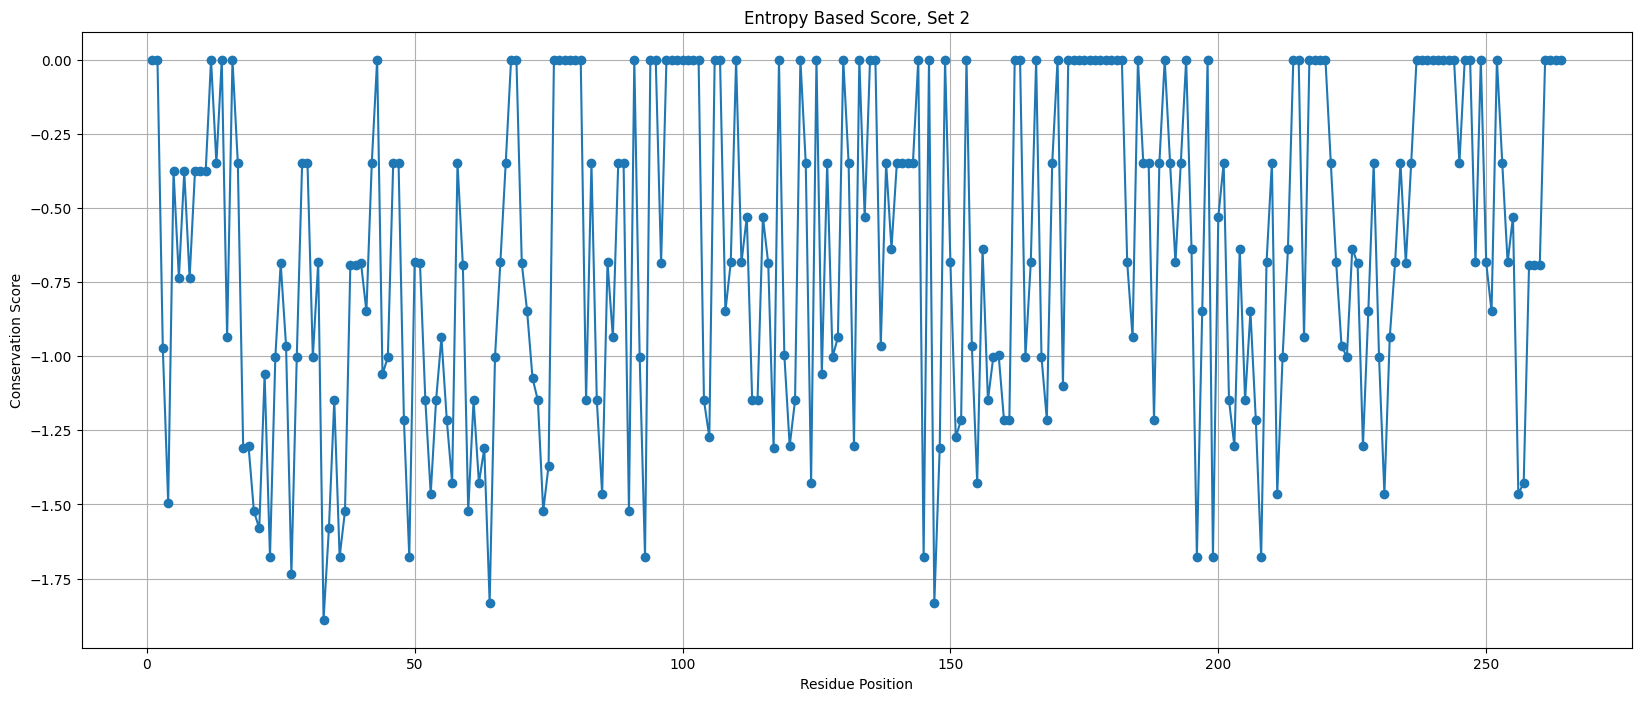

In [68]:
x = list(ebs_1.keys())
y = list(ebs_1.values())

plt.figure(figsize=(20,8))
plt.plot(x, y, marker='o')

plt.xlabel("Residue Position")
plt.ylabel("Conservation Score")
plt.title("Entropy Based Score, Set 1")

plt.grid(True)
plt.show()
print("="*100)
x = list(ebs_2.keys())
y = list(ebs_2.values())

plt.figure(figsize=(20,8))
plt.plot(x, y, marker='o')

plt.xlabel("Residue Position")
plt.ylabel("Conservation Score")
plt.title("Entropy Based Score, Set 2")

plt.grid(True)
plt.show()

In [69]:
def variance_based_score(freq, freq_total):
  scores = {}

  for n in range(len(freq)):

    residue, frequency = freq[n]
    score = 0

    for AA in frequency.keys():
      score += (frequency[AA]-freq_total[AA])**2

    score = score**0.5

    scores[residue+1] = round(score,3)

  return(scores)

vbs_1 = variance_based_score(freq_1,total_freq_1)
print(vbs_1)
print("="*100)
vbs_2 = variance_based_score(freq_2,total_freq_2)
print(vbs_2)

{1: 1.021, 2: 0.865, 3: 0.91, 4: 0.953, 5: 0.527, 6: 0.562, 7: 0.973, 8: 0.956, 9: 0.541, 10: 0.916, 11: 0.744, 12: 0.871, 13: 0.567, 14: 0.56, 15: 0.942, 16: 0.612, 17: 0.956, 18: 0.691, 19: 0.885, 20: 0.613, 21: 0.713, 22: 0.74, 23: 0.624, 24: 0.665, 25: 0.757, 26: 0.976, 27: 0.651, 28: 0.921, 29: 0.817, 30: 0.91, 31: 0.749, 32: 1.015, 33: 0.932, 34: 0.904, 35: 0.471, 36: 0.473, 37: 0.83, 38: 0.993, 39: 0.821, 40: 0.976, 41: 0.956, 42: 0.976, 43: 1.015, 44: 0.988, 45: 0.821, 46: 0.969, 47: 0.822, 48: 0.993, 49: 0.888, 50: 0.674, 51: 0.776, 52: 0.745, 53: 0.976, 54: 0.953, 55: 0.73, 56: 0.936, 57: 0.872, 58: 0.956, 59: 0.597, 60: 0.969, 61: 0.976, 62: 0.777, 63: 0.956, 64: 0.956, 65: 0.66, 66: 0.704, 67: 0.817, 68: 0.826, 69: 0.643, 70: 0.36, 71: 0.906, 72: 0.701, 73: 0.406, 74: 0.879, 75: 0.544, 76: 0.888, 77: 0.973, 78: 0.676, 79: 0.806, 80: 0.732, 81: 0.817, 82: 0.91, 83: 0.869, 84: 0.452, 85: 0.91, 86: 0.953, 87: 0.888, 88: 0.826, 89: 0.969, 90: 0.906, 91: 0.731, 92: 0.956, 93: 0.

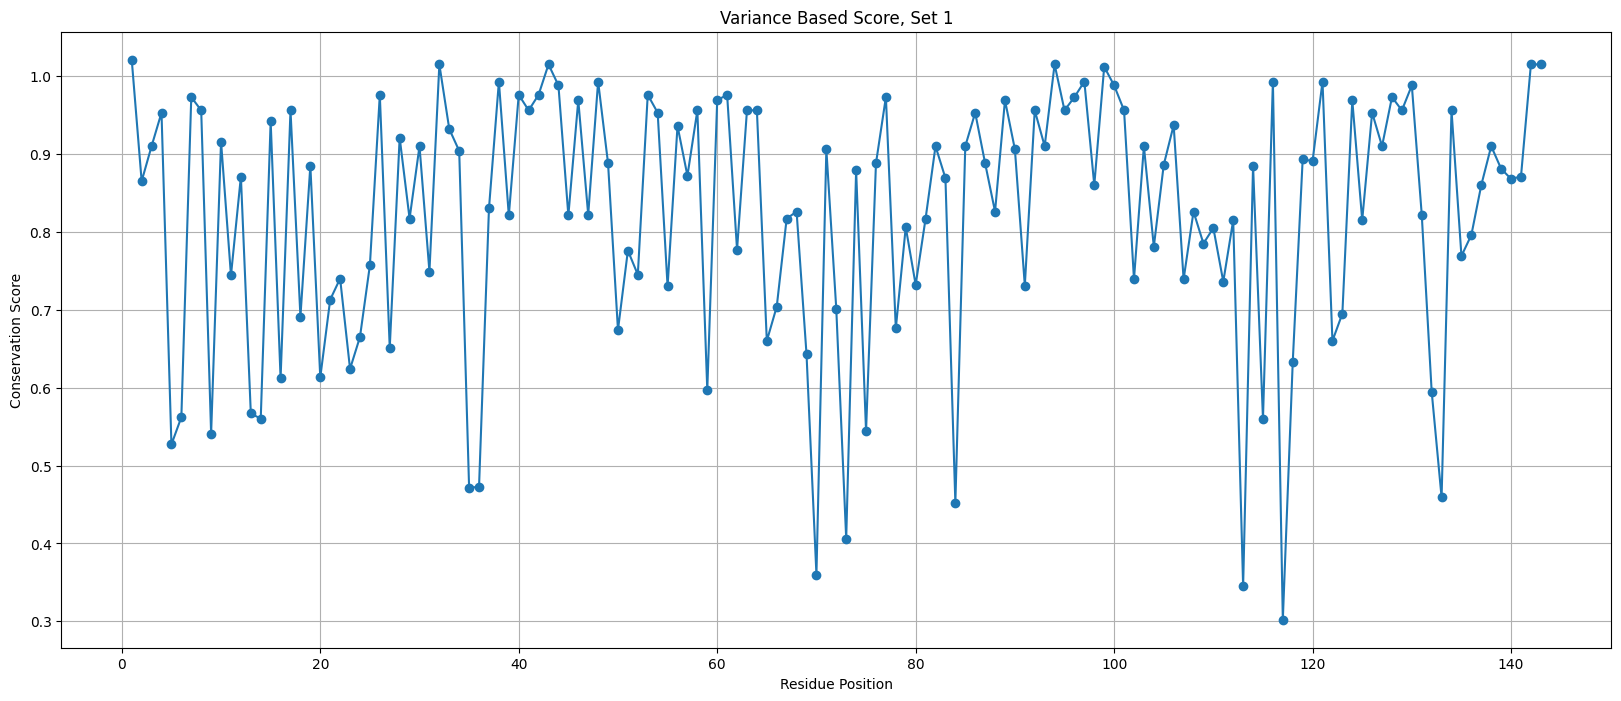

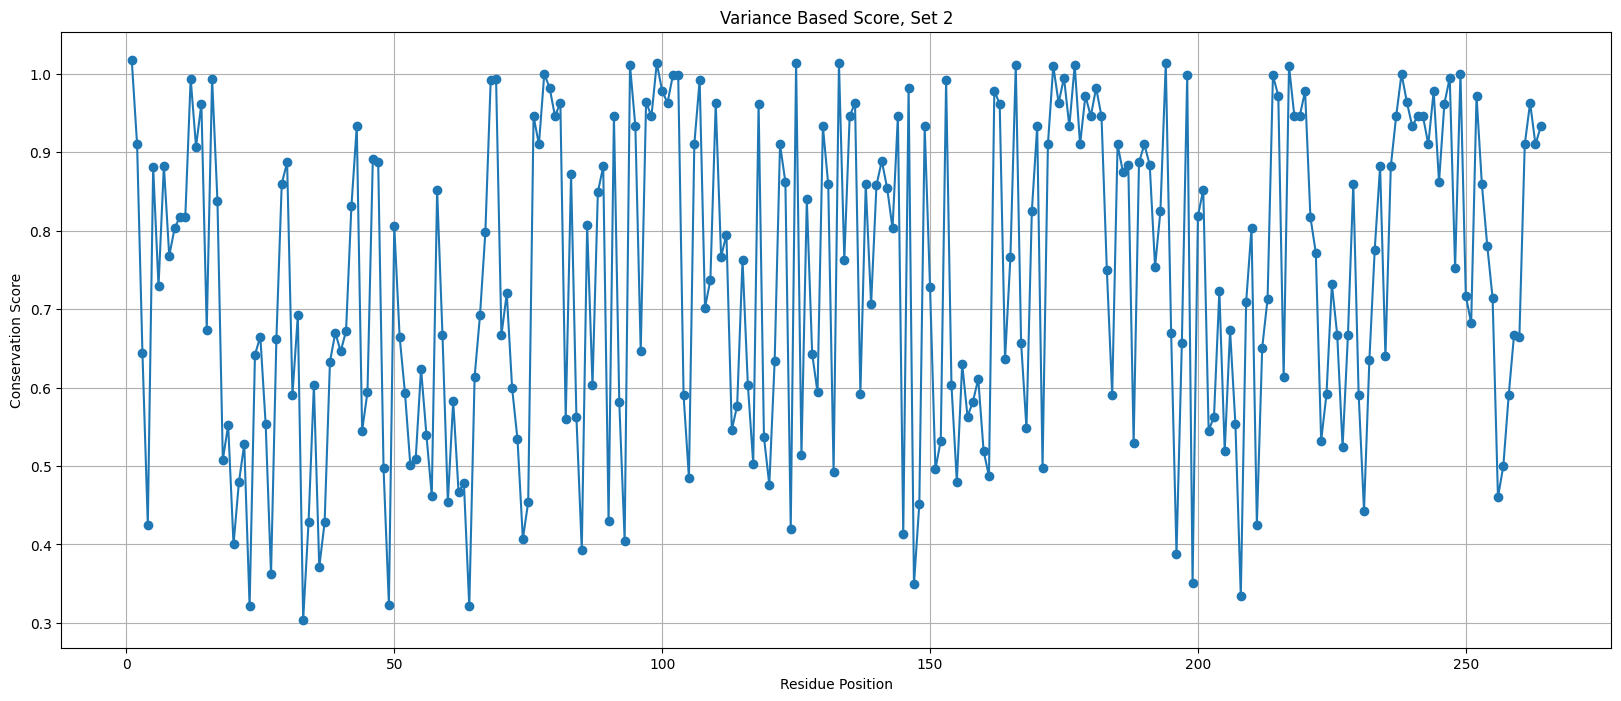

In [70]:
x = list(vbs_1.keys())
y = list(vbs_1.values())

plt.figure(figsize=(20,8))
plt.plot(x, y, marker='o')

plt.xlabel("Residue Position")
plt.ylabel("Conservation Score")
plt.title("Variance Based Score, Set 1")

plt.grid(True)
plt.show()
print("="*100)
x = list(vbs_2.keys())
y = list(vbs_2.values())

plt.figure(figsize=(20,8))
plt.plot(x, y, marker='o')

plt.xlabel("Residue Position")
plt.ylabel("Conservation Score")
plt.title("Variance Based Score, Set 2")

plt.grid(True)
plt.show()

In [71]:
# This is the Sum of pairs function according to AL2CO
def sop_based_score(freq):

  blosum62 = substitution_matrices.load("BLOSUM62")
  scores = {}

  for n in range(len(freq)):

    residue, frequency = freq[n]
    AAs = "ACDEFGHIKLMNPQRSTVWY"
    score = 0

    for AA1 in AAs:
      for AA2 in AAs:

        score += (frequency[AA1] * frequency[AA2] * blosum62[AA1, AA2])


    scores[residue+1] = round(score,3)

  return(scores)

sop_1 = sop_based_score(freq_1)
print(sop_1)
print("="*100)
sop_2 = sop_based_score(freq_2)
print(sop_2)

{1: 5.0, 2: 3.008, 3: 4.0, 4: 4.0, 5: 1.149, 6: 1.157, 7: 6.0, 8: 5.0, 9: 1.868, 10: 4.661, 11: 3.603, 12: 4.504, 13: 1.909, 14: 1.521, 15: 9.306, 16: 2.264, 17: 5.0, 18: 3.504, 19: 4.992, 20: 2.405, 21: 4.372, 22: 2.876, 23: 2.24, 24: 2.455, 25: 4.314, 26: 6.0, 27: 1.826, 28: 4.512, 29: 3.347, 30: 4.0, 31: 3.298, 32: 5.0, 33: 4.008, 34: 4.992, 35: 0.959, 36: 1.132, 37: 5.14, 38: 7.0, 39: 3.215, 40: 5.0, 41: 5.0, 42: 5.0, 43: 7.0, 44: 6.0, 45: 4.521, 46: 8.0, 47: 4.24, 48: 7.0, 49: 5.174, 50: 2.81, 51: 2.752, 52: 3.959, 53: 6.0, 54: 4.0, 55: 2.322, 56: 4.198, 57: 3.835, 58: 5.0, 59: 1.835, 60: 8.0, 61: 6.0, 62: 3.405, 63: 5.0, 64: 4.0, 65: 2.124, 66: 2.694, 67: 3.355, 68: 3.669, 69: 2.19, 70: 0.124, 71: 4.0, 72: 2.413, 73: 0.934, 74: 6.488, 75: 2.612, 76: 5.331, 77: 6.0, 78: 3.14, 79: 4.446, 80: 3.149, 81: 3.355, 82: 4.0, 83: 3.182, 84: 0.678, 85: 4.0, 86: 4.0, 87: 5.331, 88: 3.017, 89: 8.0, 90: 4.0, 91: 4.967, 92: 5.0, 93: 4.0, 94: 5.0, 95: 4.0, 96: 6.0, 97: 7.0, 98: 3.339, 99: 6.0, 1

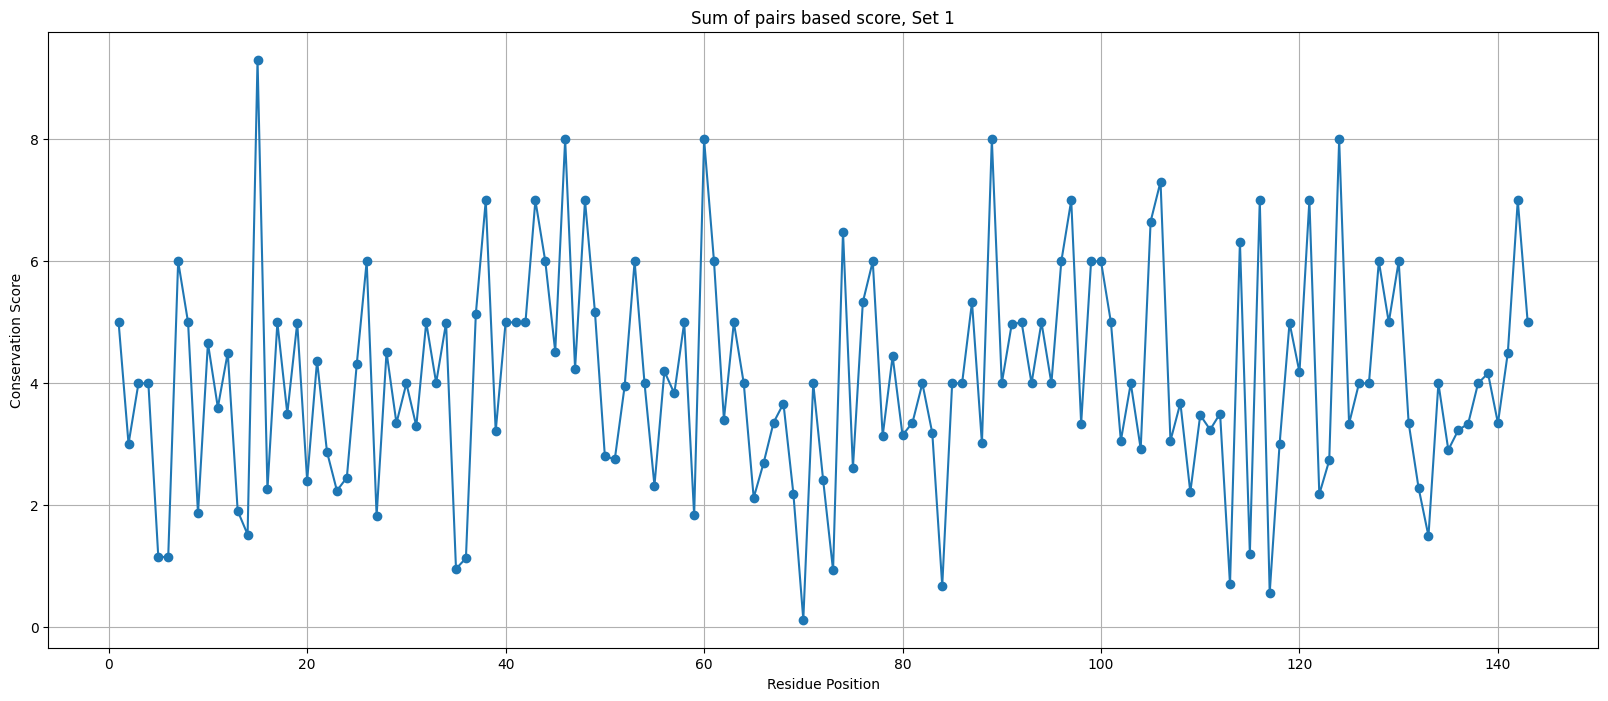

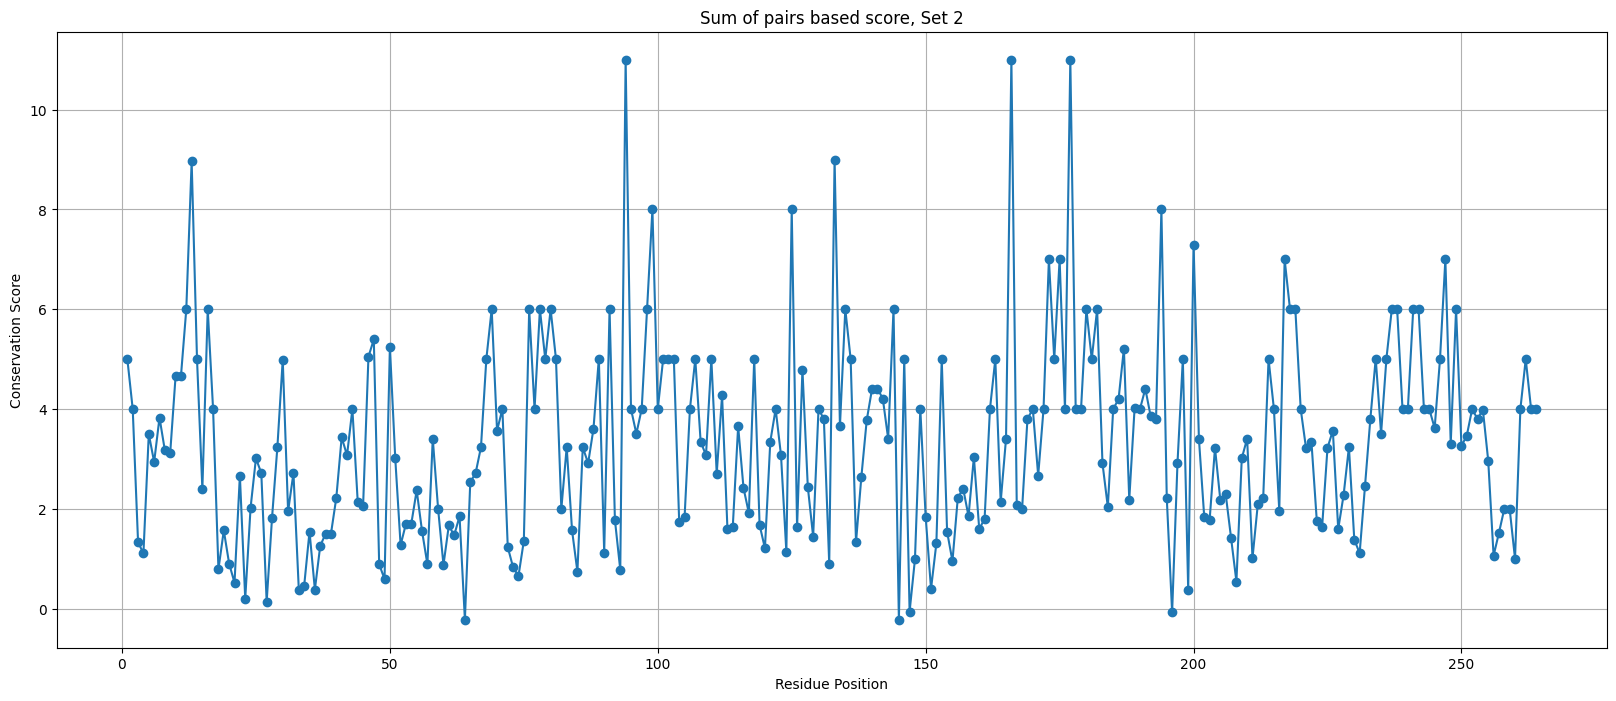

In [72]:
x = list(sop_1.keys())
y = list(sop_1.values())

plt.figure(figsize=(20,8))
plt.plot(x, y, marker='o')

plt.xlabel("Residue Position")
plt.ylabel("Conservation Score")
plt.title("Sum of pairs based score, Set 1")

plt.grid(True)
plt.show()
print("="*100)
x = list(sop_2.keys())
y = list(sop_2.values())

plt.figure(figsize=(20,8))
plt.plot(x, y, marker='o')

plt.xlabel("Residue Position")
plt.ylabel("Conservation Score")
plt.title("Sum of pairs based score, Set 2")

plt.grid(True)
plt.show()

In [73]:
# This is the Sum of pairs function according to what sir has discussed
def sop_based_score_class(freq):

  blosum62 = substitution_matrices.load("BLOSUM62")
  scores = {}

  for n in range(len(freq)):

    residue, frequency = freq[n]
    AAs = "ACDEFGHIKLMNPQRSTVWY"
    score = 0

    for AA1 in AAs:
      for AA2 in AAs:

        score += (frequency[AA1] * frequency[AA2] * blosum62[AA1, AA2])**2

    score = score**0.5

    scores[residue+1] = round(score,3)

  return(scores)

sop_1_class = sop_based_score_class(freq_1)
print(sop_1_class)
print("="*100)
sop_2_class = sop_based_score_class(freq_2)
print(sop_2_class)

{1: 5.0, 2: 3.314, 3: 4.0, 4: 4.0, 5: 1.328, 6: 1.643, 7: 6.0, 8: 5.0, 9: 1.514, 10: 4.964, 11: 2.296, 12: 4.139, 13: 1.643, 14: 1.627, 15: 9.092, 16: 1.864, 17: 5.0, 18: 1.79, 19: 4.959, 20: 2.44, 21: 4.234, 22: 2.685, 23: 2.442, 24: 2.073, 25: 3.72, 26: 6.0, 27: 2.128, 28: 4.139, 29: 3.306, 30: 4.0, 31: 2.659, 32: 5.0, 33: 4.134, 34: 4.959, 35: 1.22, 36: 0.96, 37: 4.072, 38: 7.0, 39: 3.358, 40: 5.0, 41: 5.0, 42: 5.0, 43: 7.0, 44: 6.0, 45: 4.693, 46: 8.0, 47: 4.019, 48: 7.0, 49: 4.96, 50: 2.155, 51: 2.683, 52: 4.3, 53: 6.0, 54: 4.0, 55: 2.689, 56: 4.133, 57: 3.324, 58: 5.0, 59: 1.689, 60: 8.0, 61: 6.0, 62: 3.351, 63: 5.0, 64: 4.0, 65: 2.129, 66: 3.2, 67: 3.306, 68: 3.314, 69: 2.049, 70: 0.616, 71: 4.0, 72: 2.137, 73: 0.866, 74: 6.613, 75: 1.3, 76: 4.964, 77: 6.0, 78: 2.163, 79: 4.689, 80: 3.186, 81: 3.306, 82: 4.0, 83: 3.308, 84: 0.909, 85: 4.0, 86: 4.0, 87: 4.964, 88: 3.314, 89: 8.0, 90: 4.0, 91: 4.255, 92: 5.0, 93: 4.0, 94: 5.0, 95: 4.0, 96: 6.0, 97: 7.0, 98: 3.306, 99: 6.0, 100: 6.

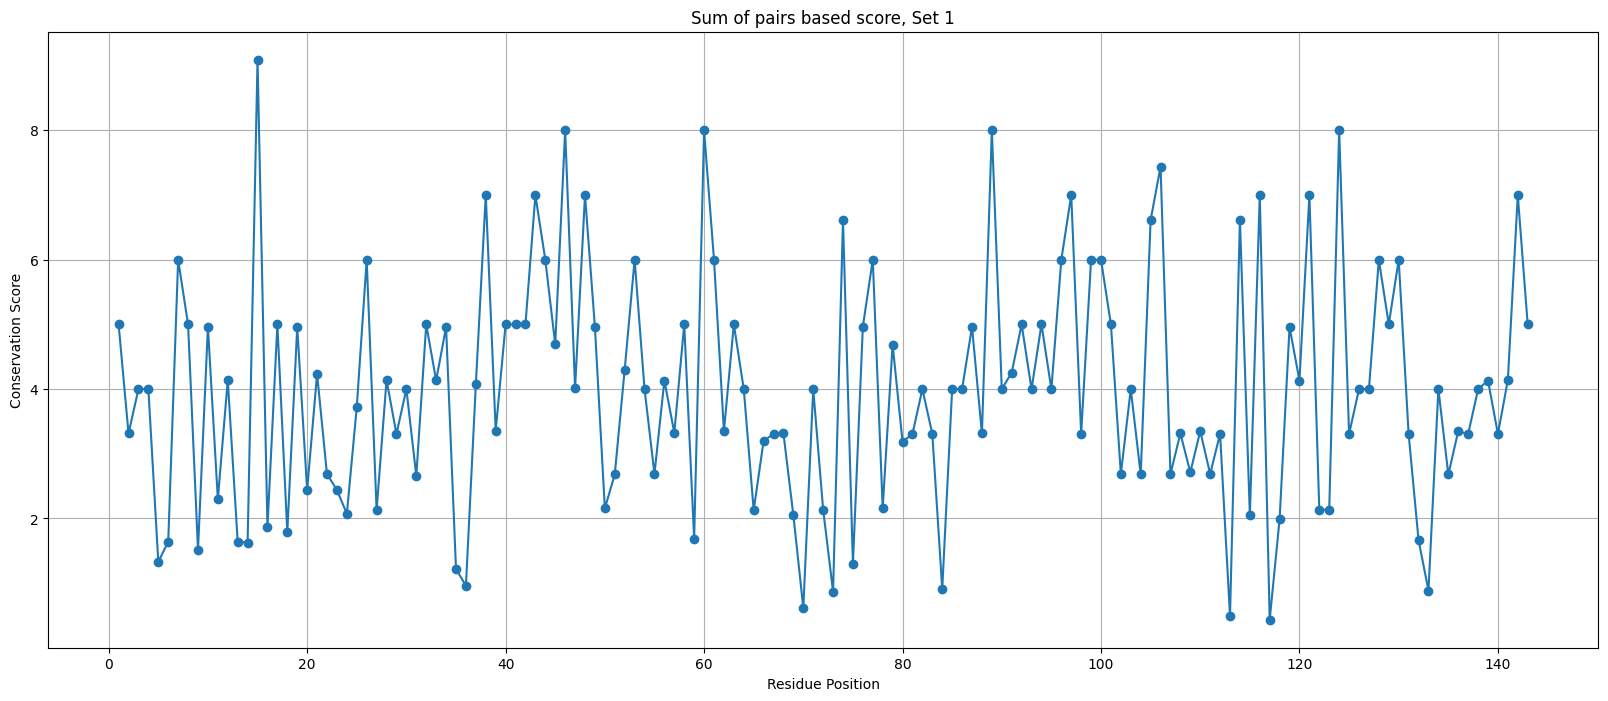

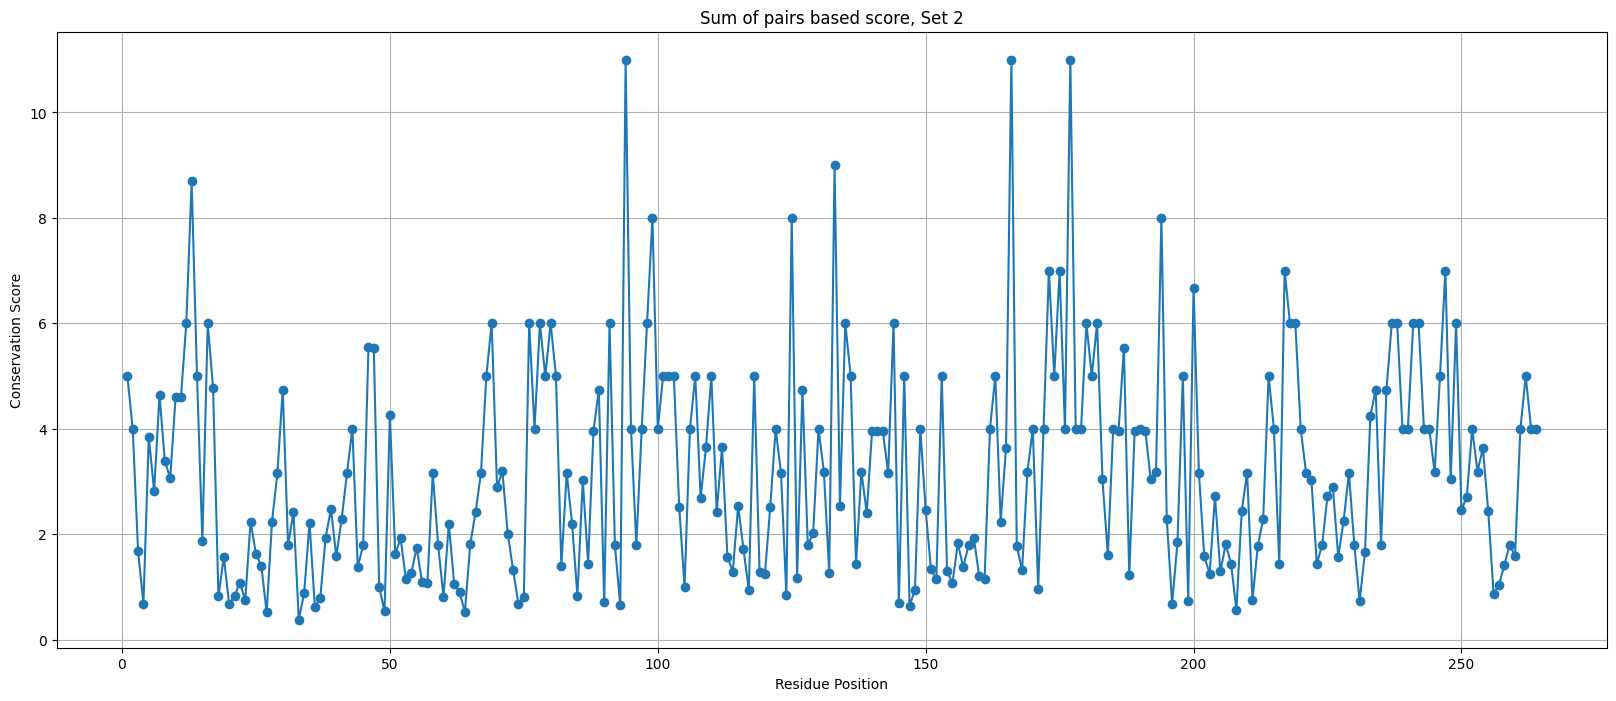

In [74]:
x = list(sop_1_class.keys())
y = list(sop_1_class.values())

plt.figure(figsize=(20,8))
plt.plot(x, y, marker='o')

plt.xlabel("Residue Position")
plt.ylabel("Conservation Score")
plt.title("Sum of pairs based score, Set 1")

plt.grid(True)
plt.show()
print("="*100)
x = list(sop_2_class.keys())
y = list(sop_2_class.values())

plt.figure(figsize=(20,8))
plt.plot(x, y, marker='o')

plt.xlabel("Residue Position")
plt.ylabel("Conservation Score")
plt.title("Sum of pairs based score, Set 2")

plt.grid(True)
plt.show()

In [75]:
# Question 4
# Reading all the required MSA files
set_1_clustal = AlignIO.read("/content/drive/MyDrive/BT3040-Assignments/Lab Assignment - 6/Clustalo-Set-1.aln-clustal_num", "clustal")
print(set_1_clustal)
print("="*125)
set_1_mafft = AlignIO.read("/content/drive/MyDrive/BT3040-Assignments/Lab Assignment - 6/Set_1_MAFFT.aln", "clustal")
print(set_1_mafft)
print("="*125)
set_1_muscle = AlignIO.read("/content/drive/MyDrive/BT3040-Assignments/Lab Assignment - 6/Set_1_MUSCLE.aln-clustalw", "clustal")
print(set_1_muscle)
print("-*"*125)

set_2_clustal = AlignIO.read("/content/drive/MyDrive/BT3040-Assignments/Lab Assignment - 6/Clustalo-Set-2.aln-clustal_num", "clustal")
print(set_2_clustal)
print("="*125)
set_2_mafft = AlignIO.read("/content/drive/MyDrive/BT3040-Assignments/Lab Assignment - 6/Set_2_MAFFT.aln", "clustal")
print(set_2_mafft)
print("="*125)
set_2_muscle = AlignIO.read("/content/drive/MyDrive/BT3040-Assignments/Lab Assignment - 6/Set_2_MUSCLE.aln-clustalw", "clustal")
print(set_2_muscle)

Alignment with 11 rows and 143 columns
-SLSDKDKAAVRALWSKIGKSADAIGNDALSRMIVVYPQTKTYF...RYR sp|P80043|HBA_TREBE
MVLSANDKSNVKSIFSKISSHAEEYGAETLERMFTTYPQTKTYF...KYR sp|P01980|HBA_APTFO
-VLSPADKTNIKSTWDKIGGHAGDYGGEALDRTFQSFPTTKTYF...KYR sp|P60529|HBA_CANLF
MVLSADDKTNIKNCWGKIGGHGGEYGEEALQRMFAAFPTTKTYF...KYR sp|P01946|HBA_RAT
-VLSAADKANVKAAWGKVGGQAGAHGAEALERMFLGFPTTKTYF...KYR sp|P01965|HBA_PIG
MVLSGEDKSNIKAAWGKIGGHGAEYGAEALERMFASFPTTKTYF...KYR sp|P01942|HBA_MOUSE
MVLSPADKTNVKTAWGKVGAHAGDYGAEALERMFLSFPTTKTYF...KYR sp|P06635|HBA_PONPY
MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYF...KYR sp|P69905|HBA_HUMAN
MVLSAADKGNVKAAWGKVGGHAAEYGAEALERMFLSFPTTKTYF...KYR sp|P01966|HBA_BOVIN
MVLSAADKTNVKAAWSKVGGHAGEYGAEALERMFLGFPTTKTYF...KYR sp|P01958|HBA_HORSE
MVLSAADKTNVKAAWSKVGGNAGEFGAEALERMFLGFPTTKTYF...KYR sp|P01959|HBA_EQUAS
Alignment with 11 rows and 143 columns
MVLSGEDKSNIKAAWGKIGGHGAEYGAEALERMFASFPTTKTYF...KYR sp|P01942|
MVLSAADKTNVKAAWSKVGGHAGEYGAEALERMFLGFPTTKTYF...KYR sp|P01958|
MVLSAADKTNVKAAWSKVGGN

In [76]:
# Analysing Set 1
freq_1_clustal = unweighted_freq(set_1_clustal)
freq_1_mafft = unweighted_freq(set_1_mafft)
freq_1_muscle = unweighted_freq(set_1_muscle)

ebs_1_clustal = entropy_based_score(freq_1_clustal)
print(ebs_1_clustal)
print("="*100)

ebs_1_mafft = entropy_based_score(freq_1_mafft)
print(ebs_1_mafft)
print("="*100)

ebs_1_muscle = entropy_based_score(freq_1_muscle)
print(ebs_1_muscle)
print("="*100)

{1: 0.0, 2: -0.305, 3: 0.0, 4: 0.0, 5: -1.121, 6: -1.16, 7: 0.0, 8: 0.0, 9: -1.169, 10: -0.305, 11: -0.586, 12: -0.305, 13: -1.034, 14: -1.16, 15: -0.305, 16: -0.916, 17: 0.0, 18: -0.689, 19: -0.305, 20: -1.034, 21: -0.886, 22: -0.474, 23: -1.034, 24: -0.908, 25: -0.886, 26: 0.0, 27: -0.886, 28: -0.305, 29: -0.305, 30: 0.0, 31: -0.886, 32: 0.0, 33: -0.305, 34: -0.305, 35: -1.295, 36: -1.367, 37: -0.474, 38: 0.0, 39: -0.474, 40: 0.0, 41: 0.0, 42: 0.0, 43: 0.0, 44: 0.0, 45: -0.474, 46: 0.0, 47: -0.6, 48: 0.0, 49: -0.305, 50: -0.586, 51: -0.6, 52: -0.586, 53: 0.0, 54: 0.0, 55: -0.6, 56: -0.305, 57: -0.305, 58: 0.0, 59: -0.86, 60: 0.0, 61: 0.0, 62: -0.6, 63: 0.0, 64: 0.0, 65: -0.76, 66: -0.76, 67: -0.305, 68: -0.305, 69: -0.86, 70: -1.673, 71: 0.0, 72: -0.586, 73: -1.594, 74: -0.305, 75: -0.995, 76: -0.305, 77: 0.0, 78: -0.76, 79: -0.6, 80: -0.76, 81: -0.305, 82: 0.0, 83: -0.305, 84: -1.414, 85: 0.0, 86: 0.0, 87: -0.305, 88: -0.305, 89: 0.0, 90: 0.0, 91: -0.76, 92: 0.0, 93: 0.0, 94: 0.0, 9

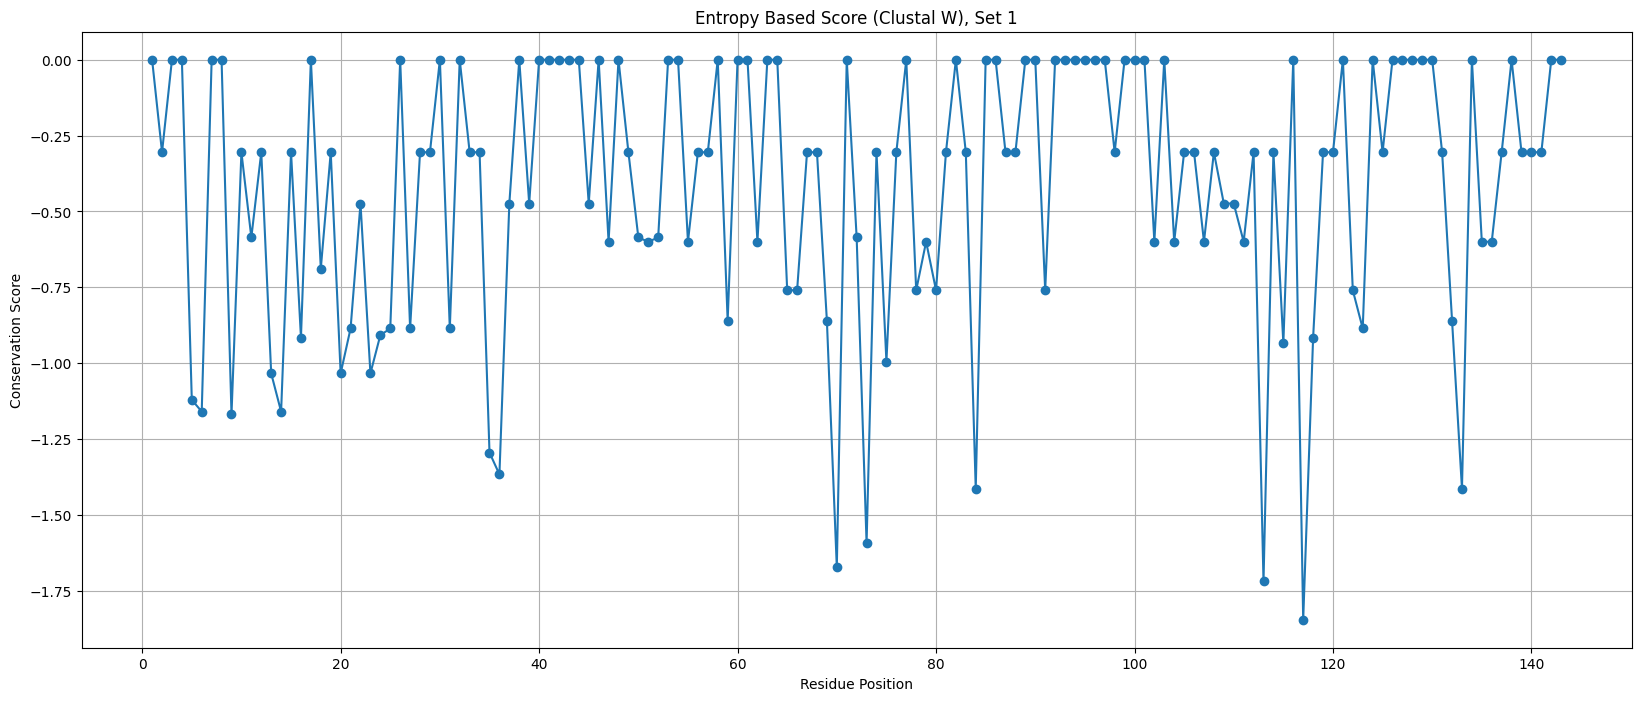

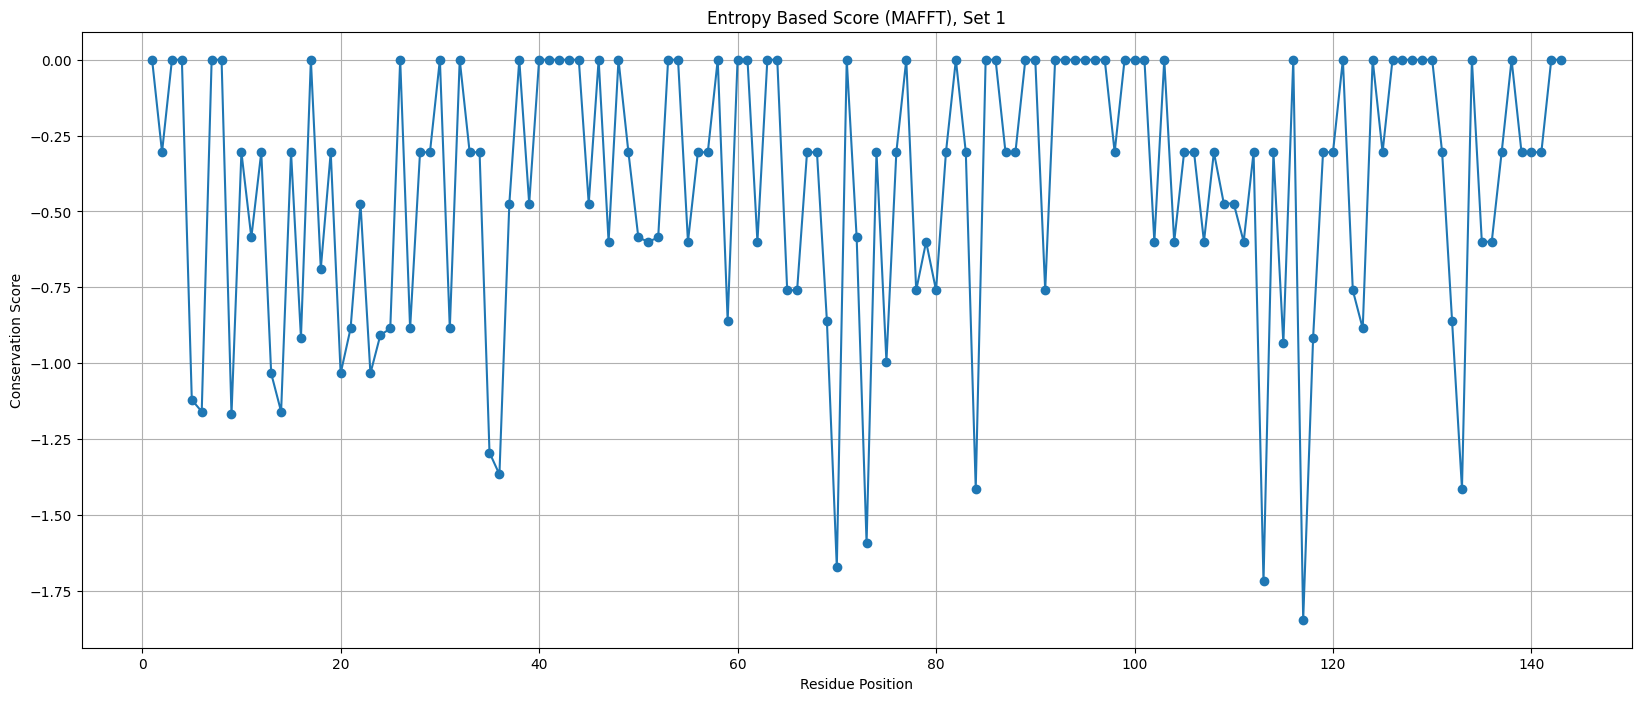

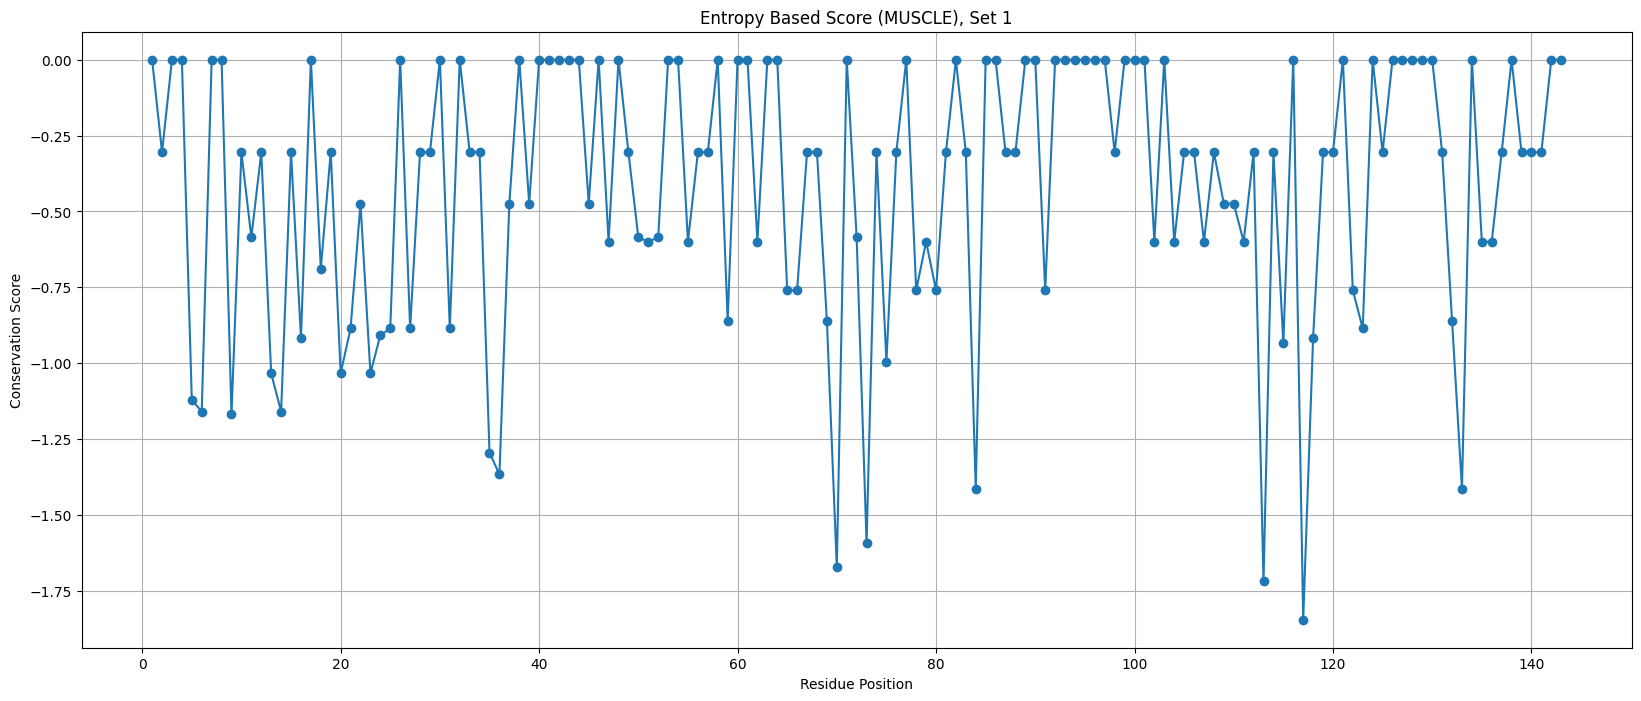

In [77]:
x = list(ebs_1_clustal.keys())
y = list(ebs_1_clustal.values())

plt.figure(figsize=(20,8))
plt.plot(x, y, marker='o')

plt.xlabel("Residue Position")
plt.ylabel("Conservation Score")
plt.title("Entropy Based Score (Clustal W), Set 1")

plt.grid(True)
plt.show()
print()

x = list(ebs_1_mafft.keys())
y = list(ebs_1_mafft.values())

plt.figure(figsize=(20,8))
plt.plot(x, y, marker='o')

plt.xlabel("Residue Position")
plt.ylabel("Conservation Score")
plt.title("Entropy Based Score (MAFFT), Set 1")

plt.grid(True)
plt.show()
print()

x = list(ebs_1_muscle.keys())
y = list(ebs_1_muscle.values())

plt.figure(figsize=(20,8))
plt.plot(x, y, marker='o')

plt.xlabel("Residue Position")
plt.ylabel("Conservation Score")
plt.title("Entropy Based Score (MUSCLE), Set 1")

plt.grid(True)
plt.show()

In [78]:
# Analysing Set 2
freq_2_clustal = unweighted_freq(set_2_clustal)
freq_2_mafft = unweighted_freq(set_2_mafft)
freq_2_muscle = unweighted_freq(set_2_muscle)

ebs_2_clustal = entropy_based_score(freq_2_clustal)
print(ebs_2_clustal)
print("="*100)

ebs_2_mafft = entropy_based_score(freq_2_mafft)
print(ebs_2_mafft)
print("="*100)

ebs_2_muscle = entropy_based_score(freq_2_muscle)
print(ebs_2_muscle)
print("="*100)

{1: 0.0, 2: 0.0, 3: -0.974, 4: -1.494, 5: -0.377, 6: -0.736, 7: -0.377, 8: -0.736, 9: -0.377, 10: -0.377, 11: -0.377, 12: 0.0, 13: -0.349, 14: 0.0, 15: -0.937, 16: 0.0, 17: -0.349, 18: -1.311, 19: -1.303, 20: -1.523, 21: -1.581, 22: -1.061, 23: -1.677, 24: -1.003, 25: -0.687, 26: -0.965, 27: -1.735, 28: -1.003, 29: -0.349, 30: -0.349, 31: -1.003, 32: -0.684, 33: -1.889, 34: -1.581, 35: -1.149, 36: -1.677, 37: -1.523, 38: -0.693, 39: -0.693, 40: -0.687, 41: -0.849, 42: -0.349, 43: 0.0, 44: -1.061, 45: -1.003, 46: -0.349, 47: -0.349, 48: -1.215, 49: -1.677, 50: -0.684, 51: -0.687, 52: -1.149, 53: -1.465, 54: -1.149, 55: -0.937, 56: -1.215, 57: -1.427, 58: -0.349, 59: -0.693, 60: -1.523, 61: -1.149, 62: -1.427, 63: -1.311, 64: -1.831, 65: -1.003, 66: -0.684, 67: -0.349, 68: 0.0, 69: 0.0, 70: -0.687, 71: -0.849, 72: -1.074, 73: -1.149, 74: -1.523, 75: -1.369, 76: 0.0, 77: 0.0, 78: 0.0, 79: 0.0, 80: 0.0, 81: 0.0, 82: -1.149, 83: -0.349, 84: -1.149, 85: -1.465, 86: -0.684, 87: -0.937, 88: -0

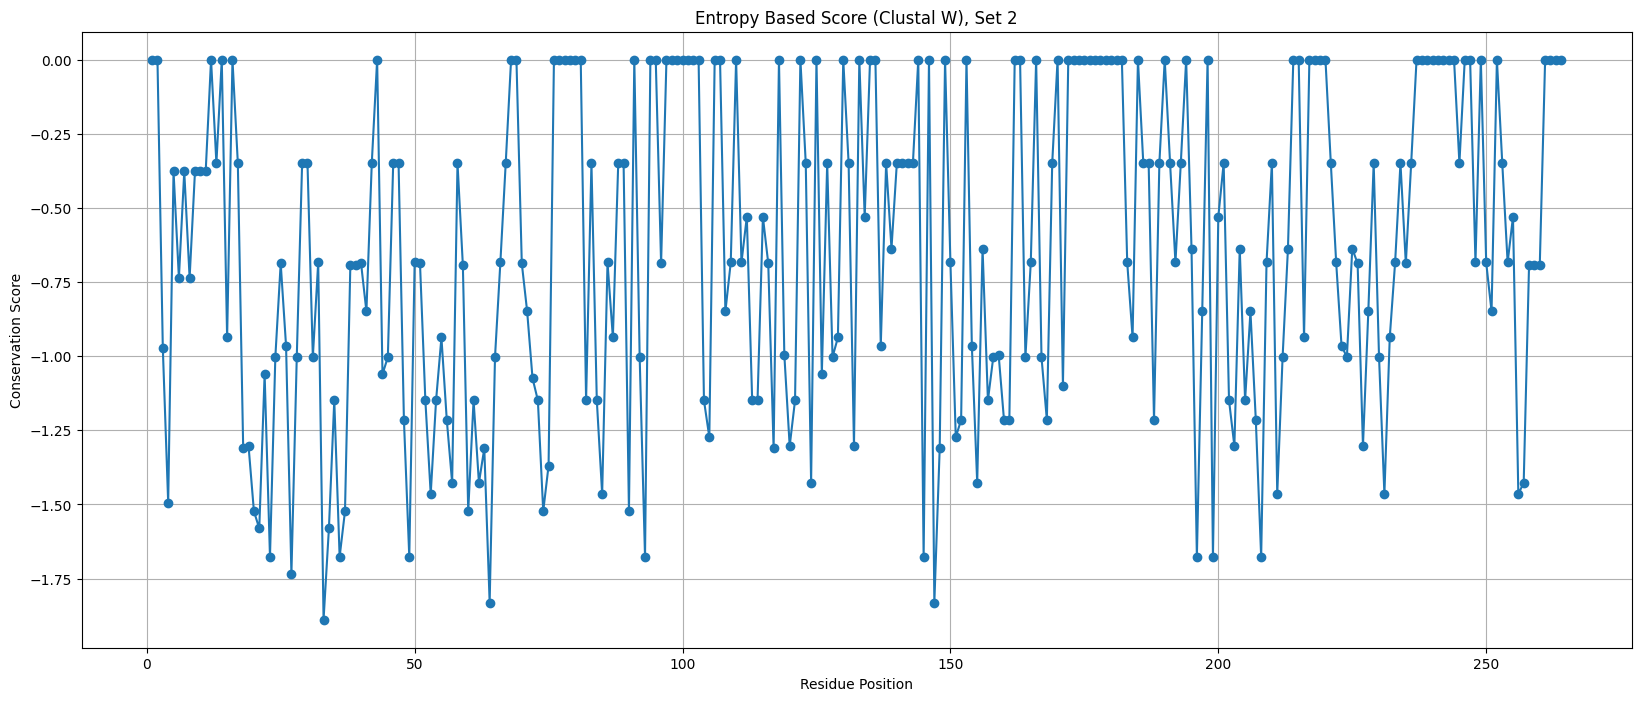

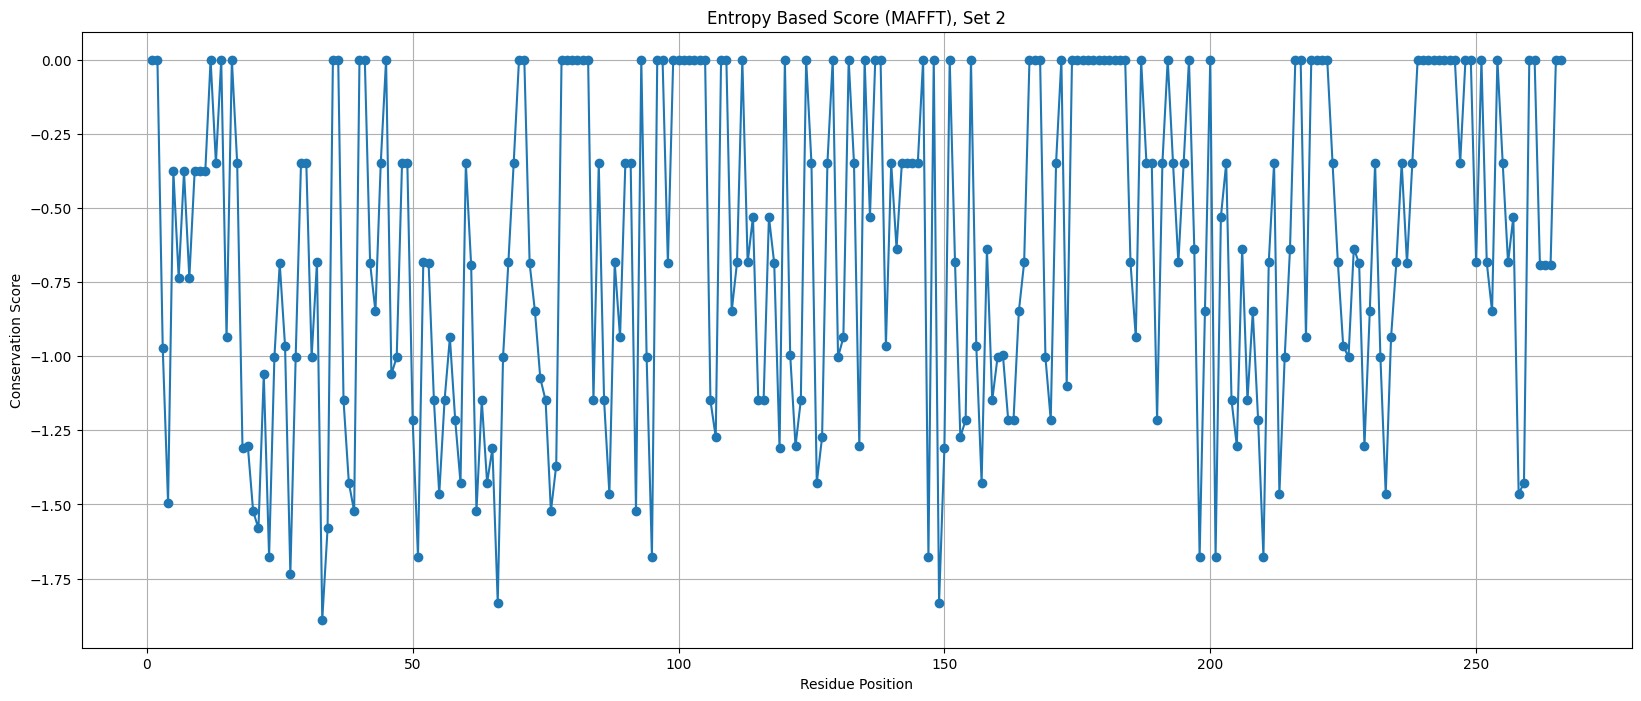

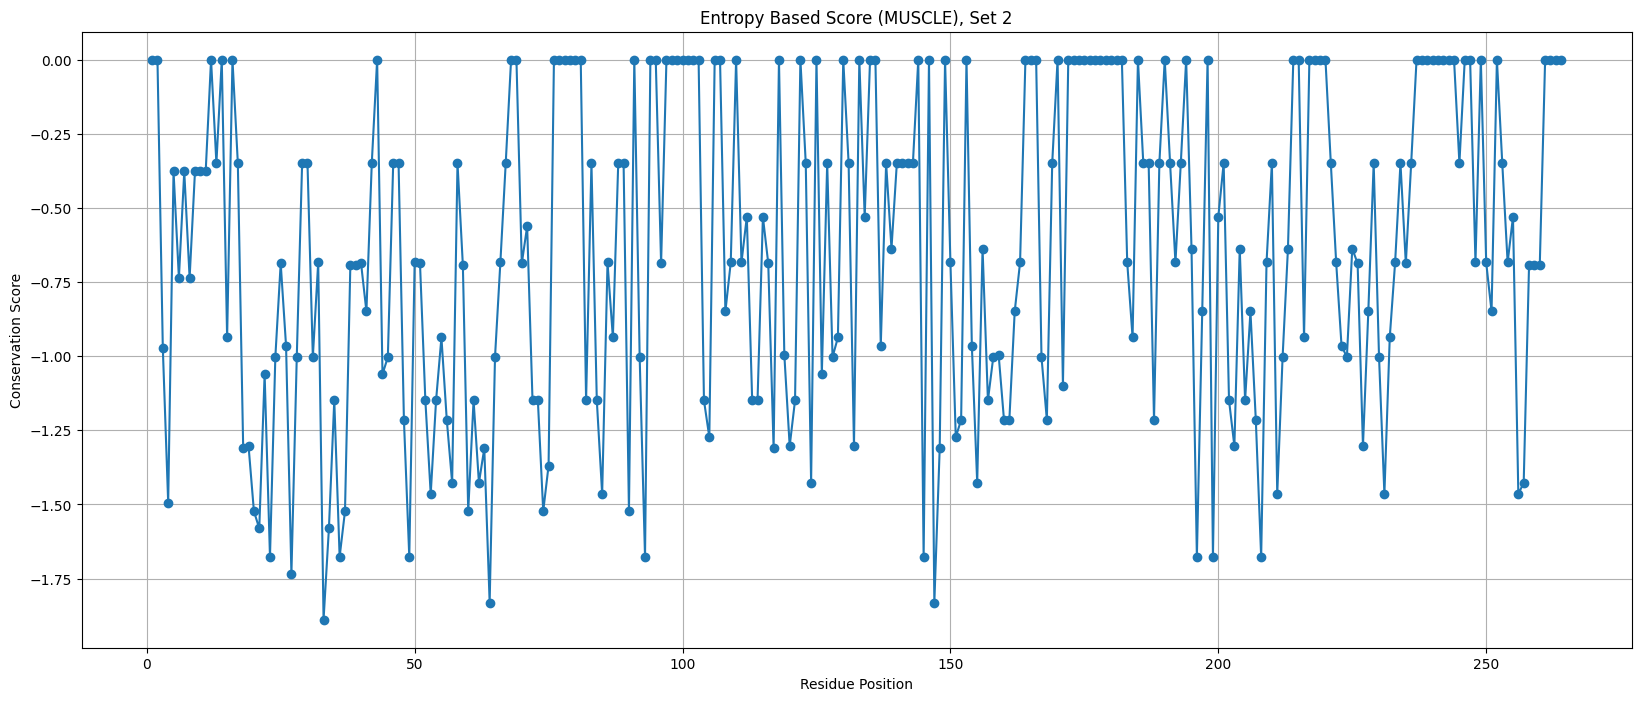

In [79]:
x = list(ebs_2_clustal.keys())
y = list(ebs_2_clustal.values())

plt.figure(figsize=(20,8))
plt.plot(x, y, marker='o')

plt.xlabel("Residue Position")
plt.ylabel("Conservation Score")
plt.title("Entropy Based Score (Clustal W), Set 2")

plt.grid(True)
plt.show()
print()

x = list(ebs_2_mafft.keys())
y = list(ebs_2_mafft.values())

plt.figure(figsize=(20,8))
plt.plot(x, y, marker='o')

plt.xlabel("Residue Position")
plt.ylabel("Conservation Score")
plt.title("Entropy Based Score (MAFFT), Set 2")

plt.grid(True)
plt.show()
print()

x = list(ebs_2_muscle.keys())
y = list(ebs_2_muscle.values())

plt.figure(figsize=(20,8))
plt.plot(x, y, marker='o')

plt.xlabel("Residue Position")
plt.ylabel("Conservation Score")
plt.title("Entropy Based Score (MUSCLE), Set 2")

plt.grid(True)
plt.show()